# Clasificación de Sonidos Urbanos


CELDA 1

In [4]:
import kagglehub
import pandas as pd

#descargar dataset
path = kagglehub.dataset_download("chrisfilo/urbansound8k")

print("Carpeta del dataset descargada en:", path)

#mostrar contenido
import os
print("os: ",os.listdir(path))

#cargar csv etiquetas 
metadata = pd.read_csv(f"{path}/UrbanSound8K.csv")
print("metadata:",metadata.head())



Carpeta del dataset descargada en: C:\Users\GarciaBe\.cache\kagglehub\datasets\chrisfilo\urbansound8k\versions\1
os:  ['fold1', 'fold10', 'fold2', 'fold3', 'fold4', 'fold5', 'fold6', 'fold7', 'fold8', 'fold9', 'UrbanSound8K.csv']
metadata:       slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


CELDA 2

In [65]:
#Definir la función de extracción
#convertir cada audio en un vector de MFCCs
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm # Para ver una barra de progreso

def extract_features(file_name):
    try:
        #cargar el audio y resampleo a 22050Hz por default
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
        
        #extraer los MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        
        #promedio para tener un vector fijo de 40 valores por audio
        mfccs_processed = np.mean(mfccs.T, axis=0)
        
    except Exception as e:
        print(f"Error con el archivo {file_name}: {e}")
        return None
     
    return mfccs_processed


extracted_features = []

print("Extrayendo características... ")
for index, row in tqdm(metadata.iterrows(), total=metadata.shape[0]):
    #contruir la ruta: path + /foldX/ + slice_file_name
    file_path = os.path.join(path, 'fold' + str(row["fold"]), str(row["slice_file_name"]))
    class_label = row["class"]
    
    data = extract_features(file_path)
    if data is not None:
        extracted_features.append([data, class_label])

#convertir a  DataFrame para procesar mas facil
features_df = pd.DataFrame(extracted_features, columns=['feature', 'class'])

Extrayendo características... 


 41%|████      | 3555/8732 [05:05<07:40, 11.24it/s]c:\Users\GarciaBe\proyectoFinal\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
 95%|█████████▌| 8324/8732 [12:54<00:21, 19.29it/s]c:\Users\GarciaBe\proyectoFinal\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
c:\Users\GarciaBe\proyectoFinal\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
100%|██████████| 8732/8732 [13:17<00:00, 10.95it/s]


CELDA 3

In [66]:
#Convertir las etiquetas como "dog_bark" en numeros (0, 1, 2...) y luego en vectores.
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

#transformar a DataFrame y limpiar valores nulos (si hay)
features_df = pd.DataFrame(extracted_features, columns=['feature', 'class'])
X = np.array(features_df['feature'].tolist())
y = np.array(features_df['class'].tolist())

#convertir etiquetas de texto a números
le = LabelEncoder()
y_encoded = to_categorical(le.fit_transform(y))

#dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Datos listos. Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Datos listos. Entrenamiento: (6985, 40), Prueba: (1747, 40)


CELDA 4

In [67]:
#Modelo de Red Neuronal MLP
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation

num_labels = y_encoded.shape[1] #esto debería ser 10

model = Sequential([
    Dense(256, input_shape=(40,)),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(512),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(256),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(num_labels),
    Activation('softmax') #para obtener probabilidades por clase
])

model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
model.summary()

c:\Users\GarciaBe\proyectoFinal\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,978 (1.05 MB)

 Trainable params: 275,978 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

CELDA 5

In [68]:
#Entenamiento
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime 

num_epochs = 100
num_batch_size = 32

start = datetime.now()

history = model.fit(X_train, y_train, 
                    batch_size=num_batch_size, 
                    epochs=num_epochs, 
                    validation_data=(X_test, y_test), 
                    verbose=1)

duration = datetime.now() - start
print("Entrenamiento completado en: ", duration)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2105 - loss: 3.7872 - val_accuracy: 0.3320 - val_loss: 1.9145
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3247 - loss: 1.8862 - val_accuracy: 0.4785 - val_loss: 1.5754
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4168 - loss: 1.6395 - val_accuracy: 0.5489 - val_loss: 1.3148
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4908 - loss: 1.4561 - val_accuracy: 0.6068 - val_loss: 1.1881
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5533 - loss: 1.3047 - val_accuracy: 0.6548 - val_loss: 1.0285
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5938 - loss: 1.1822 - val_accuracy: 0.7144 - val_loss: 0.9155
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6301 - loss: 1.1029 - val_accuracy: 0.7327 - val_loss: 0.8674
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6637 - loss: 1.0025 - val_accu

CELDA 6

In [ ]:
#GUARDAR MODELO
model.save("modelo_sonidos_urbanos.keras")

In [72]:
model = tf.keras.models.load_model("modelo_sonidos_urbanos.keras")

CELDA 7

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


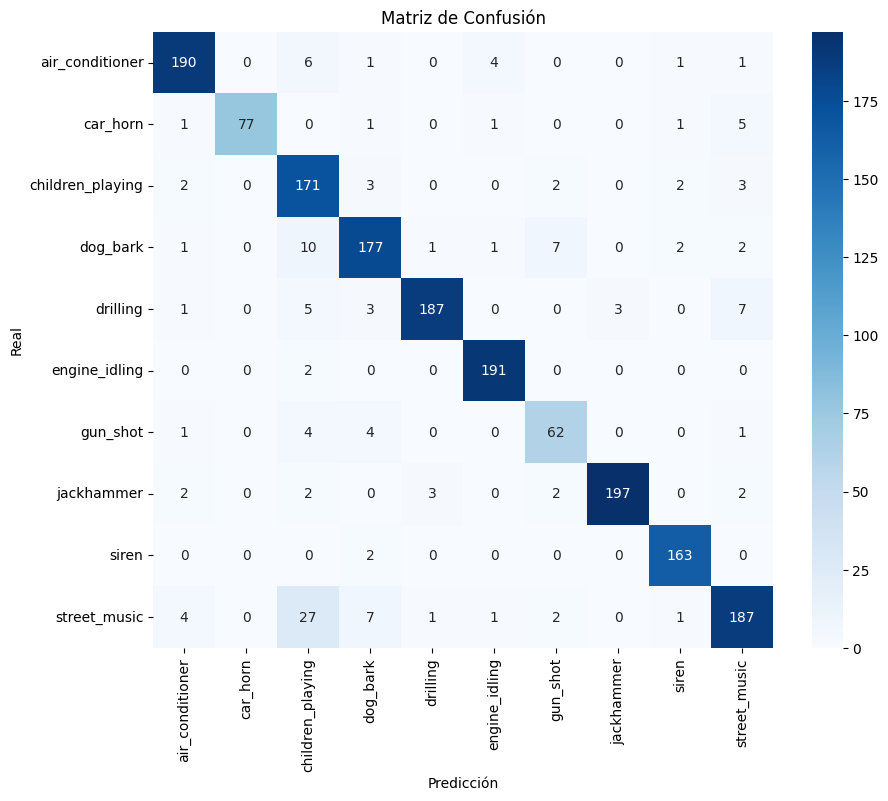

                  precision    recall  f1-score   support

 air_conditioner       0.94      0.94      0.94       203
        car_horn       1.00      0.90      0.94        86
children_playing       0.75      0.93      0.83       183
        dog_bark       0.89      0.88      0.89       201
        drilling       0.97      0.91      0.94       206
   engine_idling       0.96      0.99      0.98       193
        gun_shot       0.83      0.86      0.84        72
      jackhammer       0.98      0.95      0.97       208
           siren       0.96      0.99      0.97       165
    street_music       0.90      0.81      0.85       230

        accuracy                           0.92      1747
       macro avg       0.92      0.92      0.92      1747
    weighted avg       0.92      0.92      0.92      1747



In [10]:
#Evaluación del sistema
#Falsos Positivos y Negativos

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#obtener predicciones del conjunto de prueba
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

#generar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
classes = le.classes_ #nombre de las categorías

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

#reporte de métricas (F1-Score (rango 0-1), Falsos Positivos/Negativos por clase)
print(classification_report(y_true, y_pred, target_names=classes))

CELDA 8

In [74]:
#Evaluar el modelo con el conjunto de prueba independiente
resultados = model.evaluate(X_test, y_test, batch_size=32, verbose=1)

print("\n" + "="*30)
print(f"PÉRDIDA GLOBAL (Loss): {resultados[0]:.4f}")
print(f"EXACTITUD GLOBAL (Accuracy): {resultados[1]*100:.2f}%")
print("-"*30)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9170 - loss: 0.3594

PÉRDIDA GLOBAL (Loss): 0.3594
EXACTITUD GLOBAL (Accuracy): 91.70%
------------------------------


CELDA 9

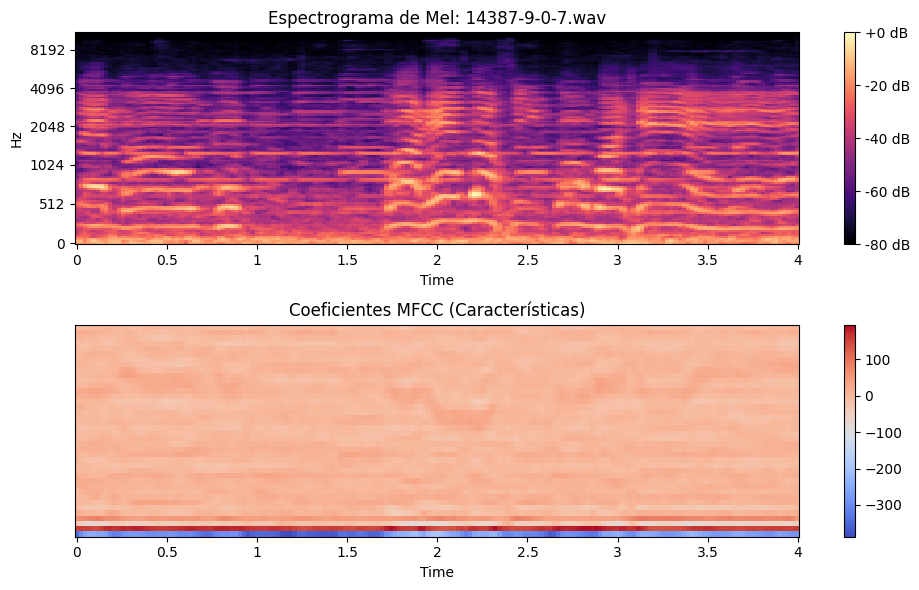

------------------------------
RESULTADO: Es STREET_MUSIC
CONFIANZA: 94.12%
LATENCIA: 0.1072 segundos
------------------------------


In [ ]:
#PREDICCIÓN Y ESPECTOGRAMAS (TEST ARCHIVO LOCAL)
import librosa.display
import matplotlib.pyplot as plt
import time

#Espectrograma de Mel y MFCC
def predict_audio(file_path):
    
    try:
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')
        
        #figura para las gráficas
        plt.figure(figsize=(10, 6))
        
        #Espectrograma de Mel
        plt.subplot(2, 1, 1)
        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Espectrograma de Mel: {os.path.basename(file_path)}')

        #MFCC
        plt.subplot(2, 1, 2)
        mfccs_viz = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        librosa.display.specshow(mfccs_viz, x_axis='time')
        plt.colorbar()
        plt.title('Coeficientes MFCC (Características)')
        
        plt.tight_layout()
        plt.show() 
        
    except Exception as e:
        print(f"Error al cargar el audio para visualizar: {e}")
        return

    #PREDICCIÓN Y TIEMPO
    start_time = time.time()
    
    #Extraer las características para el modelo (vector de 40)
    features = extract_features(file_path) 
    
    if features is not None:
        features = features.reshape(1, -1)
        
        #predicción
        prediction_probas = model.predict(features, verbose=0)
        predicted_class_index = np.argmax(prediction_probas)
        predicted_class = le.inverse_transform([predicted_class_index])[0]
        
        end_time = time.time()
        latency = end_time - start_time
        
        #resultado
        print("-" * 30)
        print(f"RESULTADO: Es {predicted_class.upper()}")
        print(f"CONFIANZA: {np.max(prediction_probas)*100:.2f}%")
        print(f"LATENCIA: {latency:.4f} segundos")
        print("-" * 30)
    else:
        print("No se pudieron extraer características para la predicción.")

#PRUEBA FINAL
test_file = os.path.join(path, 'fold2/14387-9-0-7.wav') 
predict_audio(test_file)

CELDA 10

In [ ]:
def extract_features(file_name):
    try:
        #cargar el audio
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast', duration=3.0) 
        
        #NORMALIZAR
        if np.max(np.abs(audio)) > 0:
            audio = audio * 2.0 
            audio = librosa.util.normalize(audio)
        
        #QUITAR SILENCIO
        audio, _ = librosa.effects.trim(audio, top_db=25)
        
        #RELLENAR
        if len(audio) < 3 * sample_rate:
            audio = librosa.util.fix_length(audio, size=3 * sample_rate)

        #Extraer  MFCCs (40 coeficientes)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        
        #Promedio para tener el vector fijo de 40 valores
        mfccs_processed = np.mean(mfccs.T, axis=0)
        
    except Exception as e:
        print(f"Error con el archivo {file_name}: {e}")
        return None
     
    return mfccs_processed

In [ ]:
#PREDICCIÓN Y ESPECTROGRAMAS (TEST ACTUALIZADO)
import librosa.display
import matplotlib.pyplot as plt
import time
import numpy as np

def predict_audio(file_path):
    try:
        
        audio, sr = librosa.load(file_path, res_type='kaiser_fast', duration=3.0)
        
        #NORMALIZACION
        if np.max(np.abs(audio)) > 0:
            audio = audio * 2.0 
            audio = librosa.util.normalize(audio)
            
        #RECORTE DE SILENCIO
        audio, _ = librosa.effects.trim(audio)
        
        #FIJAR LARGO
        audio = librosa.util.fix_length(audio, size=3 * sr)

        #FIGURA PARA LAS GRAFICAS
        plt.figure(figsize=(10, 6))
        
        #Espectrograma de Mel
        plt.subplot(2, 1, 1)
        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Espectrograma (Procesado): {os.path.basename(file_path)}')

        #MFCC
        plt.subplot(2, 1, 2)
        mfccs_viz = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        librosa.display.specshow(mfccs_viz, x_axis='time')
        plt.colorbar()
        plt.title('Coeficientes MFCC')
        
        plt.tight_layout()
        plt.show() 
        
    except Exception as e:
        print(f"Error al cargar el audio: {e}")
        return

    #PREDICCION Y TIEMPO
    start_time = time.time()
    
    features = extract_features(file_path) 
    
    if features is not None:
        features = features.reshape(1, -1)
        
        prediction_probas = model.predict(features, verbose=0)
        predicted_class_index = np.argmax(prediction_probas)
        predicted_class = le.inverse_transform([predicted_class_index])[0]
        
        end_time = time.time()
        latency = end_time - start_time
        
        print("-" * 30)
        print(f"RESULTADO: Es {predicted_class.upper()}")
        print(f"CONFIANZA: {np.max(prediction_probas)*100:.2f}%")
        print(f"LATENCIA: {latency:.4f} segundos")
        print("-" * 30)

CELDA 11

In [36]:
#TEST EN VIVO
import sounddevice as sd
from scipy.io.wavfile import write
import numpy as np

def grabar_y_predecir(segundos=3, fs=22050):
    print(f"Grabando durante {segundos} segundos...")
    
    #acceder a micrófono
    grabacion = sd.rec(int(segundos * fs), samplerate=fs, channels=1)
    sd.wait()  #esperar a que termine la grabación
    
    print("Grabación finalizada.")
    
    #guardar temporalmente para procesar
    nombre_archivo = "test_microfono.wav"
    write(nombre_archivo, fs, grabacion)
    
    #usar función de predicción existente
    predict_audio(nombre_archivo)



CELDA 12

Grabando durante 3 segundos...
Grabación finalizada.


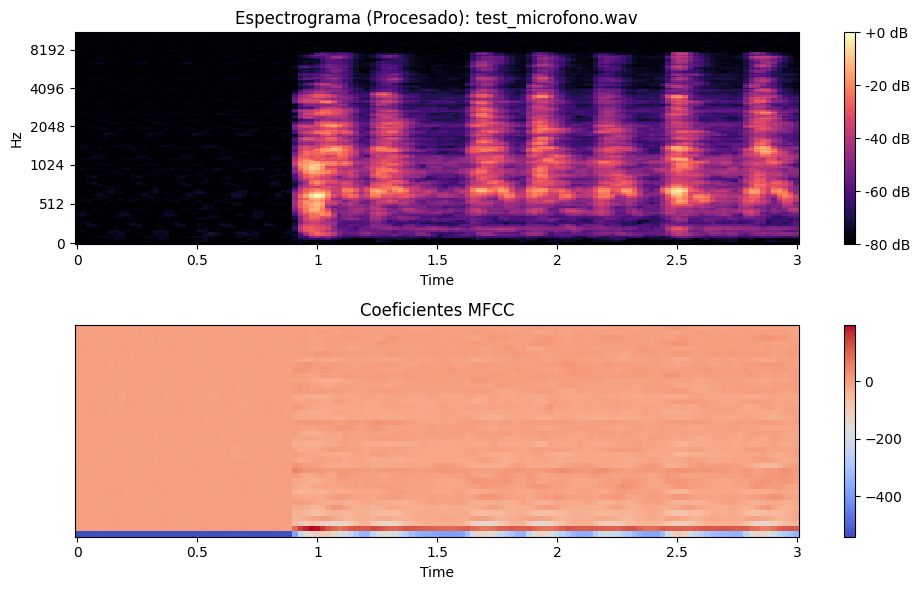

------------------------------
RESULTADO: Es DOG_BARK
CONFIANZA: 97.68%
LATENCIA: 0.1316 segundos
------------------------------


In [80]:
#test en vivo
grabar_y_predecir()

CELDA 13

Curvas de Aprendizaje

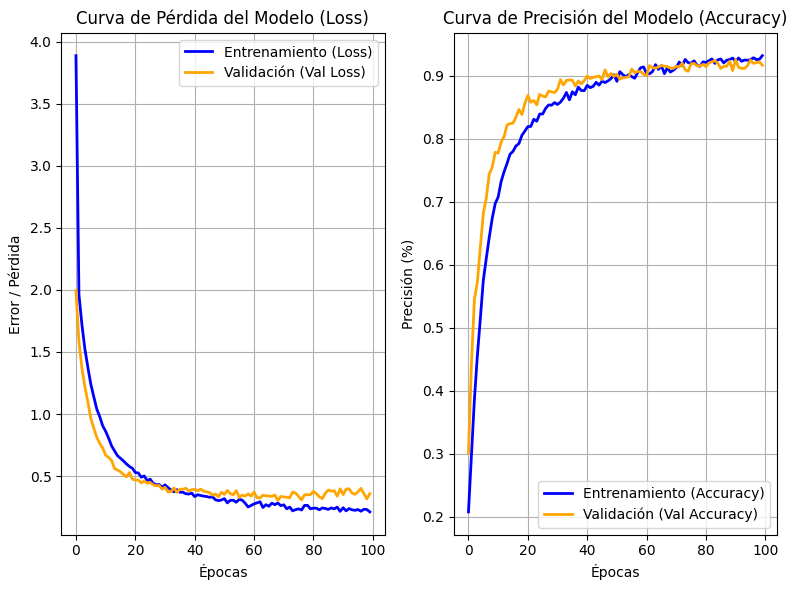

In [ ]:
import matplotlib.pyplot as plt

#subgráficas
plt.figure(figsize=(8, 6))

#GRÁFICA 1: CURVA DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Loss)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación (Val Loss)', color='orange', linewidth=2)
plt.title('Curva de Pérdida del Modelo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Error / Pérdida')
plt.legend()
plt.grid(True)

#GRÁFICA 2: CURVA DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento (Accuracy)', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación (Val Accuracy)', color='orange', linewidth=2)
plt.title('Curva de Precisión del Modelo (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión (%)')
plt.legend(){}
plt.grid(True)

plt.tight_layout()
plt.show()

CELDA 14

Main Graph

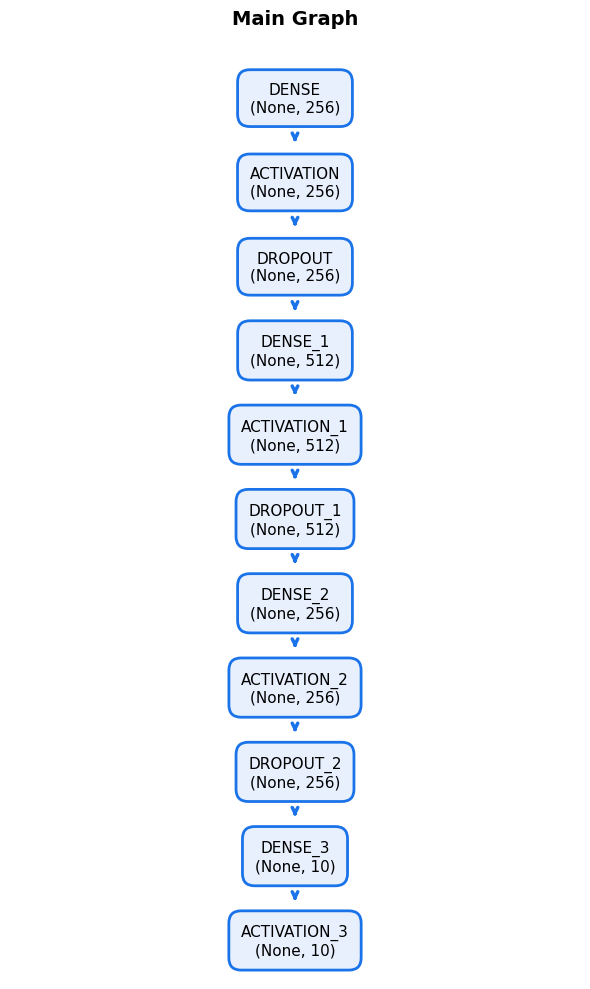

In [ ]:
#MAIN GRAPH
import matplotlib.pyplot as plt

#figura
fig, ax = plt.subplots(figsize=(6, 10))
ax.axis('off')

#Capas del modelo
capas = []
for i, layer in enumerate(model.layers):
    nombre = layer.name.upper()

    shape = str(layer.output.shape) 
    capas.append(f"{nombre}\n{shape}")

#Bloques secuenciales 
num_capas = len(capas)
for i, texto in enumerate(capas):
    #Calcular posiciones verticales dinámicamente
    y_pos = 1 - (i / num_capas) - 0.05
    
    #Bloque de la capa)
    ax.text(0.5, y_pos, texto, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F0FE', edgecolor='#1A73E8', lw=2))
    
    #Flecha que conecta al siguiente bloque
    if i < num_capas - 1:
        y_siguiente = 1 - ((i + 1) / num_capas) - 0.05
        #Ajustar la flecha para que apunte hacia abajo
        ax.annotate('', xy=(0.5, y_siguiente + 0.04), xytext=(0.5, y_pos - 0.04),
                    arrowprops=dict(arrowstyle="->", color='#1A73E8', lw=2.5))

plt.title("Main Graph", fontsize=14, weight='bold', pad=20)
plt.tight_layout()

plt.show()